In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import geopandas as gpd 
from pathlib import Path
import seamless_3dep as s3dep
import rioxarray as rxr

In [14]:
sierras = gpd.read_file('../../data/misc/sierras_polygon_gmba.geojson')

In [10]:
bbox = (-119.8, 37.7, -119.2, 38.2)
data_dir = '../../data/3dep'

In [11]:
# Download DEM
tiff_files = s3dep.get_dem(bbox, data_dir, 60)

# Convert to xarray.DataArray
dem = s3dep.tiffs_to_da(tiff_files, bbox, crs=4326)

ValueError: `bbox` must be within (-180.0033333325668, 50.99666666673079, -126.99666666814491, 72.0033333327681).

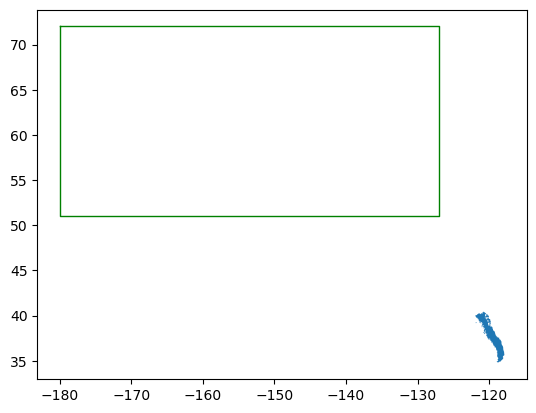

In [15]:
region = [  {"lon": -180.0033333325668, "lat": 72.0033333327681},
            {"lon": -126.99666666814491, "lat": 72.0033333327681},
            {"lon": -126.99666666814491, "lat": 50.99666666673079},
            {"lon": -180.0033333325668, "lat": 50.99666666673079},
            {"lon": -180.0033333325668, "lat": 72.0033333327681}  ]

region_lon = [e["lon"] for e in region]
region_lat = [e["lat"] for e in region]

fig, ax = plt.subplots()
sierras.plot(ax=ax)
ax.plot(region_lon, region_lat, linewidth=1, color='g');

### Access 3DEP elevation data for plotting site fig